# Forward Propagation

Forward propagation is the process of sending inputs through the network layer by layer to get an output.

Think of it like this: a student receives a question, reads it, and then uses their knowledge step by step to answer.

A neural network does the same thing. It takes the input, multiplies it with weights, adds bias, and passes it through an activation function.

### Very simple idea
If you give a model some numbers like 2 and 3, it will do some math:

$z = w_1x_1 + w_2x_2 + b$

Then it may apply a function like ReLU or sigmoid to decide the final output.

### Example
Suppose an input is:
- $x_1 = 2$
- $x_2 = 3$

And weights are:
- $w_1 = 0.5$
- $w_2 = 1.0$
- $b = 1$

Then:

$z = 0.5 \times 2 + 1.0 \times 3 + 1 = 1 + 3 + 1 = 5$

So the signal moves forward and gives a value.

This is forward propagation: moving information from input to output.

![Forward propagation](images/forward_prop.svg)

### Internal implementation
At each layer:
1. multiply input with weights
2. add bias
3. apply activation function
4. pass result to next layer

This keeps happening until the network produces a final prediction.

### Real-world use
- image recognition
- voice recognition
- spam detection
- price prediction

### Limitation
Forward propagation only tells us the output. It does not tell us how wrong we are or how to fix the mistakes. That is where backward propagation comes in. Basically, the model is doing its best, but it still needs a reality check.

---

# Backward Propagation

Backward propagation, or backpropagation, is the process of going backward through the network to find out how wrong the prediction was.

This is the moment when the model says, "Oops, I messed up. Let me fix it."

### Simple definition
After the network gives an output, we compare it with the true answer using a loss function.

Then we calculate how much each weight contributed to the error and adjust the weights.

### Why is it important?
Without backpropagation, the model would just guess randomly and never improve.

It is like learning from your mistakes in a test:
- answer wrong
- check what went wrong
- improve next time

### Diagram

![Backward propagation](images/backward_prop.svg)

### Process
1. Forward pass gives output
2. Compare output with true label
3. Compute loss
4. Calculate gradients
5. Update weights
6. Repeat many times

### How it calculates
The basic idea is:

$\frac{\partial L}{\partial w}$

This means: how much does the loss change when a weight changes?

If the error is large, the model changes the weight more.

### Loss function
A loss function tells us how bad the prediction is.

#### 1) Log Loss
Used mainly for binary classification.

Formula:

$L = -[y \log(p) + (1-y)\log(1-p)]$

Where:
- $y$ = true label
- $p$ = predicted probability

This helps the model understand how wrong it was.

![Log loss example](images/forward_prop.svg)

#### 2) MSE (Mean Squared Error)
Used for regression problems.

Formula:

$MSE = \frac{1}{n} \sum (y - \hat{y})^2$

This measures the average squared difference between actual and predicted values.

### Formula for calculating new weights
The weights are updated using:

$w = w - \eta \frac{\partial L}{\partial w}$

Where:
- $w$ = weight
- $\eta$ = learning rate
- $\frac{\partial L}{\partial w}$ = gradient

This means: move the weight in a direction that reduces the loss.

### Optimizer: Gradient Descent
Gradient descent is the optimization method that helps the model move toward the smallest loss.

It is like walking downhill on a mountain to find the lowest point.

![Gradient descent](images/gradient_descent.svg)

### Important idea
The model does not jump randomly. It keeps making small adjustments until the error becomes smaller.

That is the whole trick behind learning.

---

# EPOCH

An epoch is one complete pass of the entire training dataset through the neural network.

### Simple explanation
Imagine you have 100 students and you teach them all once. That is one epoch.

Then you teach them again and again. Each time the model learns a little more.

### Real-world example
If you have 1000 images in the training set, one epoch means the model sees all 1000 images once.

After that, it calculates errors, updates weights, and starts again for the next epoch.

### Why epochs matter?
More epochs often allow the model to learn better, but too many can cause overfitting.

So it is a balance.

### Example with calculations
Suppose:
- dataset has 4 examples
- learning rate = 0.1
- after first pass, loss is high

The model adjusts weights.

Then it goes through the same 4 examples again.

This second pass is the second epoch.

After many epochs, the model becomes better at making predictions.

### Final idea
- Forward propagation = move input forward
- Backward propagation = fix mistakes
- Epoch = one full training round

This is the basic flow of training a neural network.

# Vanishing Gradient Problem

## 1. What is a gradient?

A **gradient** tells a neural network how much each weight should change to reduce its error.

Imagine you are walking down a hill and want to reach the lowest point. The gradient tells you:

- which direction is downhill
- how steep the hill is
- how big your next step should be

In a neural network, the gradient plays a similar role. It tells the model how to improve its weights. Without useful gradients, the model is basically trying to learn while wearing a blindfold. Very educational. Not very efficient.

## 2. What is the vanishing gradient problem?

The **vanishing gradient problem** happens when gradients become extremely small while moving backward through many layers of a neural network.

When the gradient becomes almost zero:

- the weights in early layers change very little
- those layers learn extremely slowly
- training may appear stuck
- the network may fail to learn useful early patterns

The word *vanishing* is used because the gradient becomes smaller and smaller until it is almost gone.

## 3. Why does it happen?

During backpropagation, the chain rule multiplies many gradients together.

A simplified version looks like this:

$$
\frac{\partial L}{\partial w_1} =
\frac{\partial L}{\partial a_n}
\times
\frac{\partial a_n}{\partial a_{n-1}}
\times \cdots \times
\frac{\partial a_2}{\partial a_1}
\times
\frac{\partial a_1}{\partial w_1}
$$

Here:

- $L$ is the loss, or the model's mistake
- $w_1$ is an early weight
- $a_1, a_2, \ldots, a_n$ are values from different layers
- each fraction is a small gradient

If many numbers smaller than $1$ are multiplied together, the result becomes very small.

For example:

$$
0.5 \times 0.5 \times 0.5 \times 0.5 = 0.0625
$$

After many more multiplications, the answer can become almost zero. The calculator is not broken. The gradient has simply gone on a very long vacation.

---

# 4. How it happens step by step

Suppose a network has many layers and each layer produces a gradient of approximately $0.2$.

For 5 layers:

$$
0.2^5 = 0.00032
$$

For 10 layers:

$$
0.2^{10} = 0.0000001024
$$

That is already a tiny number. If the learning rate is $0.1$, the weight update becomes even smaller:

$$
\text{weight update} = 0.1 \times 0.0000001024
$$

$$
\text{weight update} = 0.00000001024
$$

The weight technically changes, but so little that the model may need an impressive amount of time to notice.

## A simple analogy

Imagine passing a message through ten people. Each person whispers only half of what they heard:

- Person 1 passes $50\%$.
- Person 2 passes $50\%$ of that.
- Person 3 passes $50\%$ of what remains.
- Continue until person 10.

Very little of the original message survives. Gradients can lose information in a similar way as they travel backward through many layers.

---

# 5. The role of sigmoid and tanh

Older neural networks often used sigmoid or tanh in many hidden layers.

## Sigmoid derivative

The derivative of sigmoid is:

$$
sigmoid'(x) = sigmoid(x)(1-sigmoid(x))
$$

The largest possible value of this derivative is $0.25$.

That means a sigmoid gradient is never larger than $0.25$. If many sigmoid layers are multiplied together:

$$
0.25 \times 0.25 \times 0.25 \times 0.25 = 0.00390625
$$

For 20 layers:

$$
0.25^{20} \approx 9.09 \times 10^{-13}
$$

That is extremely close to zero.

## Saturation

Sigmoid and tanh can become **saturated**. Saturation means the function becomes almost flat at very large positive or negative inputs.

A flat curve has a tiny slope. A tiny slope means a tiny gradient. A tiny gradient means tiny learning updates.

The model is still doing mathematics, but mostly the kind that produces no visible progress.

---

# 6. Worked example problem

Suppose a three-layer network has these approximate gradients during backpropagation:

- Layer 3 gradient: $0.2$
- Layer 2 gradient: $0.2$
- Layer 1 gradient: $0.2$

The gradient reaching the first layer is:

$$
0.2 \times 0.2 \times 0.2 = 0.008
$$

If the learning rate is $0.1$:

$$
\text{weight update} = 0.1 \times 0.008 = 0.0008
$$

Now imagine 20 or 50 layers. The multiplication continues, and the update can become so small that the early layers barely learn.

## What does this mean?

The later layers may learn because they are close to the output and receive a stronger gradient. The early layers may learn very slowly because the gradient has shrunk while traveling backward.

For an image model, early layers should learn simple patterns such as edges. If they cannot learn properly, later layers receive poor information. The whole team suffers because one early teammate never got the instructions.

---

# 7. Symptoms of vanishing gradients

You may suspect vanishing gradients when:

- training loss decreases extremely slowly
- early-layer weights barely change
- later layers learn faster than early layers
- gradients printed during training are close to zero
- the model performs poorly even after many epochs
- increasing the number of layers makes training much worse

A flat loss curve is not always caused by vanishing gradients, so we should inspect gradients instead of blaming the first mathematical concept that sounds dramatic.

---

# 8. How can we reduce the problem?

## 1. Use ReLU-family activation functions

ReLU is defined as:

$$
ReLU(x)=max(0,x)
$$

For positive values, its derivative is $1$. A gradient of $1$ does not shrink during multiplication, so ReLU often trains deep networks better than sigmoid or tanh.

Leaky ReLU and PReLU allow a small gradient for negative inputs and can reduce the problem of neurons becoming permanently inactive.

## 2. Use good weight initialization

Weights that are too small can make signals and gradients shrink. Methods such as **Xavier initialization** and **He initialization** choose starting weights carefully.

- Xavier initialization is often suitable for sigmoid or tanh.
- He initialization is often suitable for ReLU-family functions.

## 3. Use batch normalization

Batch normalization keeps intermediate values in a more useful range. This can make training faster and help gradients behave more reliably.

## 4. Use residual connections

Residual connections provide a shorter path for information and gradients to travel through the network.

A residual layer can be imagined as:

$$
output = F(x) + x
$$

The original input $x$ is added to the transformed output $F(x)$. This helps the gradient travel backward without passing through every transformation in a difficult long chain.

## 5. Use suitable network architecture

For sequence problems, architectures such as **LSTM** and **GRU** were designed to help information survive across many time steps.

## 6. Monitor the gradients

During training, inspect gradient sizes for different layers. This helps us discover the problem instead of waiting for the model to silently give up.

---

# 9. Vanishing gradient versus exploding gradient

These are opposite problems:

| Problem | What happens? | Result |
|---|---|---|
| Vanishing gradient | Gradients become extremely small | Learning becomes very slow or stops |
| Exploding gradient | Gradients become extremely large | Updates become unstable and the loss may become huge |

If many gradients are smaller than $1$, they may vanish. If many gradients are larger than $1$, they may explode.

The goal is not to make gradients huge. The goal is to keep them useful and stable. Neural networks, like people, do not usually perform well at either extreme.

---

# 10. A tiny numerical experiment

The next code cell shows how repeatedly multiplying a number below $1$ makes it shrink. This is the basic arithmetic behind vanishing gradients.

For example:

$$
0.25^1=0.25
$$

$$
0.25^5=0.0009765625
$$

$$
0.25^{20}\approx 9.09\times10^{-13}
$$

The graph makes the change easier to see than a page full of numbers pretending to be exciting.

---

# 11. Final summary

- A gradient tells the model how to change its weights.
- During backpropagation, gradients are multiplied through many layers.
- If those gradients are mostly smaller than $1$, their product can become almost zero.
- This is the **vanishing gradient problem**.
- Early layers then learn very slowly or stop learning.
- Sigmoid and tanh are more likely to cause this because their derivatives can become very small.
- ReLU-family functions, careful initialization, batch normalization, residual connections, and suitable architectures can help.
- Always check actual gradient values before deciding what is wrong.

In one sentence:

> Vanishing gradients happen when the learning signal becomes so tiny while traveling backward that early layers barely receive instructions to improve.

0.25^5 = 0.0009765625
0.25^20 = 9.095e-13
0.2^10 = 1.024e-07


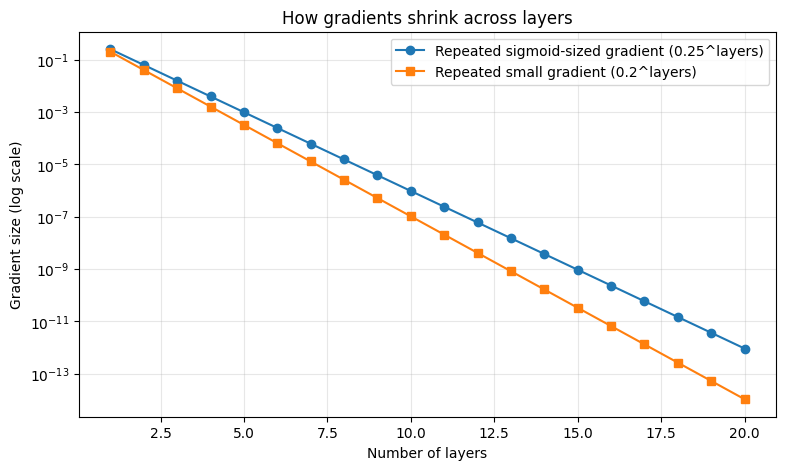

In [2]:
import numpy as np
import matplotlib.pyplot as plt

layers = np.arange(1, 21)
sigmoid_gradient = 0.25 ** layers
small_gradient = 0.2 ** layers

print(f"0.25^5 = {0.25 ** 5}")
print(f"0.25^20 = {0.25 ** 20:.3e}")
print(f"0.2^10 = {0.2 ** 10:.3e}")

plt.figure(figsize=(9, 5))
plt.plot(layers, sigmoid_gradient, marker="o", label="Repeated sigmoid-sized gradient (0.25^layers)")
plt.plot(layers, small_gradient, marker="s", label="Repeated small gradient (0.2^layers)")
plt.yscale("log")
plt.xlabel("Number of layers")
plt.ylabel("Gradient size (log scale)")
plt.title("How gradients shrink across layers")
plt.grid(alpha=0.3)
plt.legend()
plt.show()